# Packages

In [72]:
! pip install datasets plotly nbformat seaborn matplotlib scipy numpy pandas -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Données

In [3]:
from datasets import load_dataset

ds = load_dataset("Uris001/credit-risk-eda")

data = ds["train"].to_pandas()
print(data.shape)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--Uris001--credit-risk-eda. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an a

(31415, 16)


## Affichage de la base de donnée

In [4]:
data.head()

,Age,Annual Income,Home Ownership,Employment Length (Years),Loan Purpose,Loan Grade,Loan Amount,Interest Rate,Default Status,Loan % of Income,Previous Default,Credit History Length (Years),LTI Group,Income Group,Age Group,Interest Rate Group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,No,2,Low,Very Low,18–25,Medium
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,No,3,Very High,Very Low,18–25,High
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,No,2,Very High,High,18–25,Very High
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Very High,Medium,18–25,Very High
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,No,2,High,Very Low,18–25,Very Low


# Statistiques Descriptives

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31415 entries, 0 to 31414
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            31415 non-null  int64  
 1   Annual Income                  31415 non-null  int64  
 2   Home Ownership                 31415 non-null  str    
 3   Employment Length (Years)      31415 non-null  float64
 4   Loan Purpose                   31415 non-null  str    
 5   Loan Grade                     31415 non-null  str    
 6   Loan Amount                    31415 non-null  int64  
 7   Interest Rate                  31415 non-null  float64
 8   Default Status                 31415 non-null  int64  
 9   Loan % of Income               31415 non-null  float64
 10  Previous Default               31415 non-null  str    
 11  Credit History Length (Years)  31415 non-null  int64  
 12  LTI Group                      31415 non-null  str    
 1

In [9]:
data.describe()

,Age,Annual Income,Employment Length (Years),Loan Amount,Interest Rate,Default Status,Loan % of Income,Credit History Length (Years)
count,31415.000000,3.141500e+04,31415.000000,31415.000000,31415.000000,31415.000000,31415.000000,31415.000000
mean,27.743466,6.646909e+04,4.786567,9659.268661,11.044241,0.215629,0.169582,5.817030
std,6.206875,5.262203e+04,4.037482,6335.486029,3.204214,0.411265,0.106268,4.062565
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.941000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,84.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [20]:
from statistique_descriptive import Statistique_Descriptives
from statistique_descriptive import analyse_categorielle


# I. Statistiques descriptives Univariée

### Statistiques descriptives de l'Age des clients

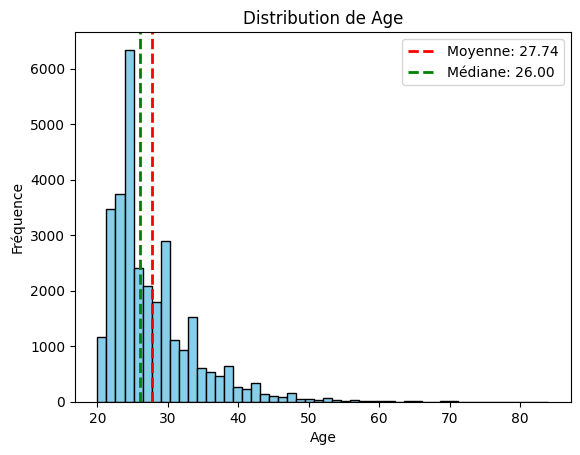

In [11]:
Statistique_Descriptives(data, "Age")

Un premier control exploratoire montre que les données l'age des individus est dans une fourchette assez raisonnable comprise entre 20 et 84 ans. Cela semble très normale vu la situation des individus et l'esperance de vie à la naissance. 

### Analyse du nombre d'année de travail

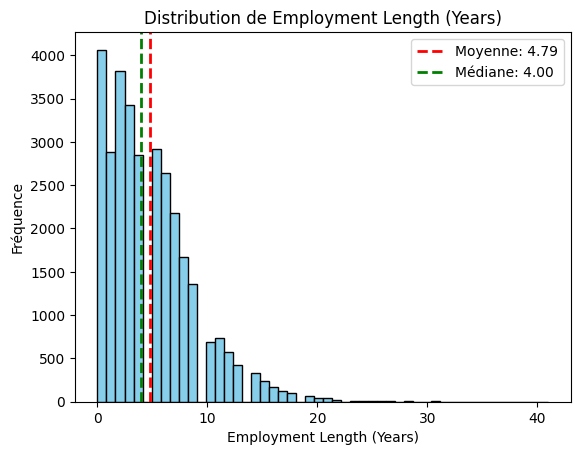

In [14]:
Statistique_Descriptives(data, "Employment Length (Years)")

Une analyse aussi de nombre d'année d'experience des individus montre que cela est aussi normale avec la periode allant de 0 à 41 ans d'experience de travail.

### Analyse des données des taux d'interet

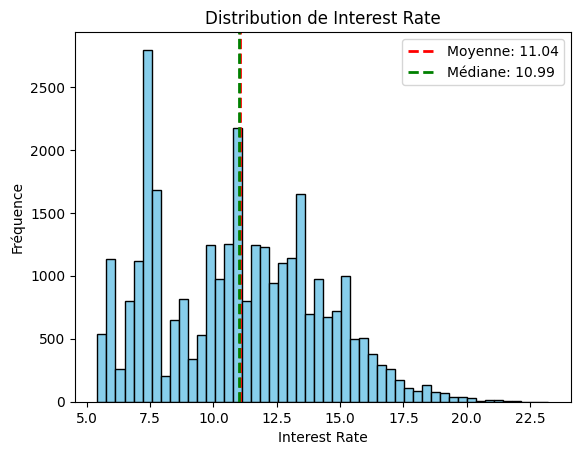

In [17]:
Statistique_Descriptives(data, "Interest Rate")

Les informations sur les taux d'interet montre que le mode est obtenus pour des valeurs proches de 7,5% ce qui reflète reellement la nature des taux d'interet sur les prèts bancaires. 

### Données sur les montants empruntés

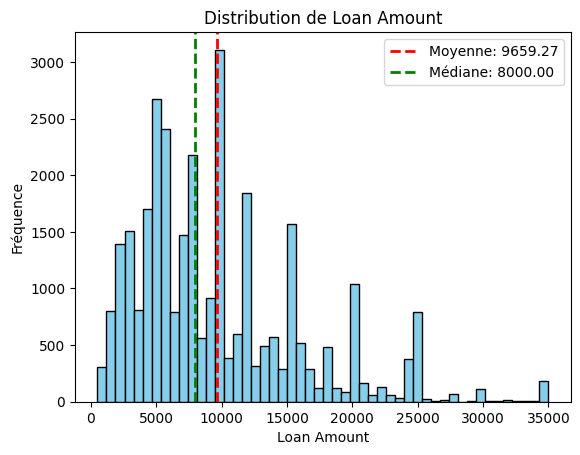

In [18]:
Statistique_Descriptives(data, "Loan Amount")

Le montant maximal des montants prets est de 35000 euros.

### Statistique descriptives sur le statut des clients

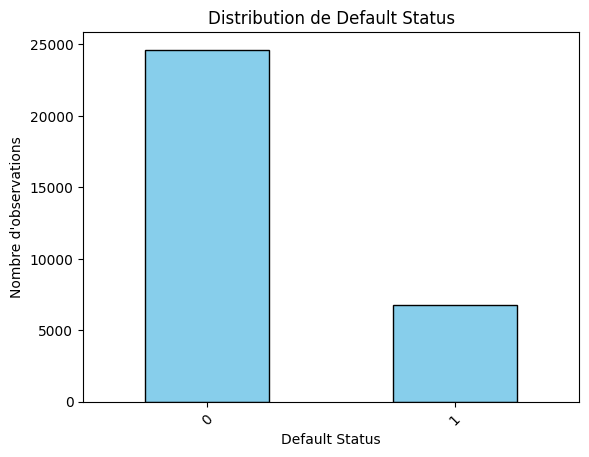

--- Default Status ---
Default Status
0    24641
1     6774
Name: count, dtype: int64




In [21]:
analyse_categorielle(data, "Default Status")

Il existe environ 21,5 % des clients de la banque qui sont en defaut de paiement de leur pret.

### Analyse des defaut précedement des clients

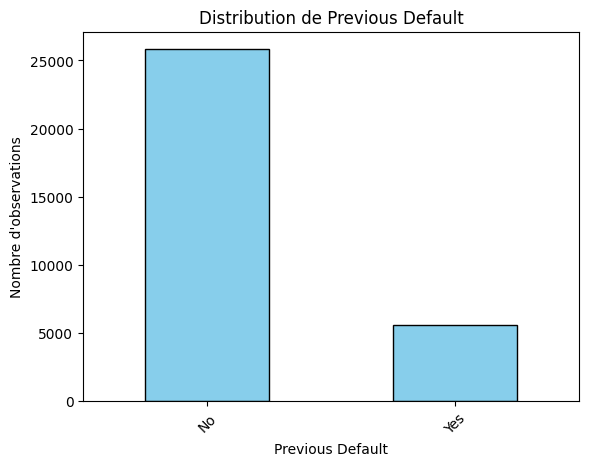

--- Previous Default ---
Previous Default
No     25830
Yes     5585
Name: count, dtype: int64




In [22]:
analyse_categorielle(data, "Previous Default")

Seulement 17,5% des clients avait fait un defaut sur leur credit precedemment.

### Analyse de Loan-to-Income Group (Montant du pret/Revenu)

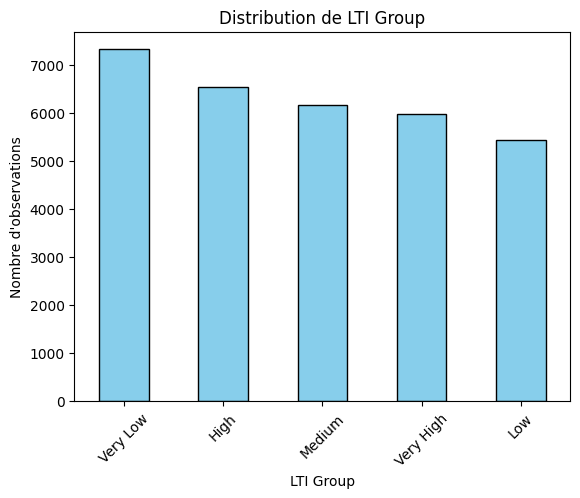

--- LTI Group ---
LTI Group
Very Low     7321
High         6528
Medium       6157
Very High    5981
Low          5428
Name: count, dtype: int64




In [34]:
analyse_categorielle(data, "LTI Group")

### Loan Grade

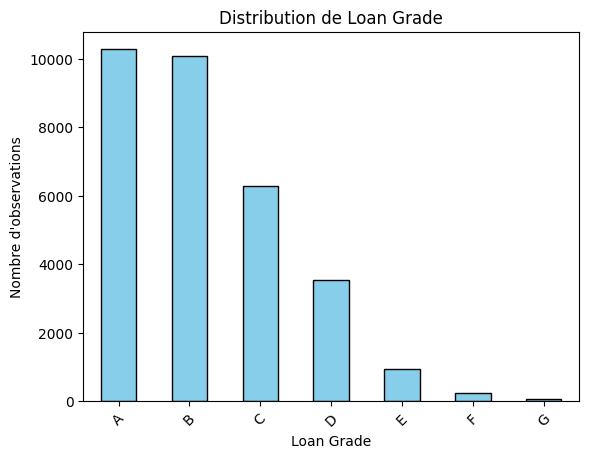

--- Loan Grade ---
Loan Grade
A    10274
B    10088
C     6283
D     3529
E      943
F      234
G       64
Name: count, dtype: int64




In [38]:
analyse_categorielle(data, "Loan Grade")

# Statistique descriptives bivariés

In [59]:
from statistique_descriptive import bivarié_cat_num
from statistique_descriptive import bivarié_cat_cat
from scipy import stats

### Income vs Grade

<Figure size 800x400 with 0 Axes>

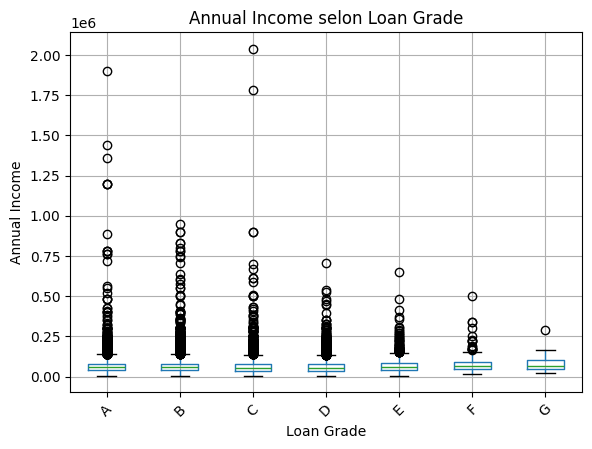

              count          mean           std      min      25%      50%  \
Loan Grade                                                                   
A           10274.0  67385.017131  53923.237462   5500.0  40800.0  58650.0   
B           10088.0  66895.234338  50010.550644   4080.0  39600.0  56000.0   
C            6283.0  64543.908961  57528.960771   4000.0  37000.0  53832.0   
D            3529.0  63762.900255  46216.719445   4800.0  36000.0  54000.0   
E             943.0  71333.238600  52056.996943   4200.0  40000.0  59712.0   
F             234.0  77967.547009  57542.713700  14400.0  44800.0  65503.5   
G              64.0  76773.296875  43327.436469  19200.0  45996.0  66900.0   

                  75%        max  
Loan Grade                        
A            80004.00  1900000.0  
B            80000.00   948000.0  
C            77000.00  2039784.0  
D            75000.00   703800.0  
E            83700.00   648000.0  
F            92083.25   499800.0  
G           10246

In [37]:
bivarié_cat_num(data, "Loan Grade", "Annual Income")

### LTI vs Grade

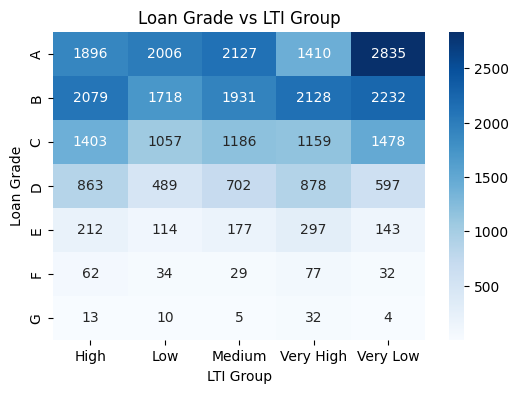

LTI Group   High   Low  Medium  Very High  Very Low
Loan Grade                                         
A           1896  2006    2127       1410      2835
B           2079  1718    1931       2128      2232
C           1403  1057    1186       1159      1478
D            863   489     702        878       597
E            212   114     177        297       143
F             62    34      29         77        32
G             13    10       5         32         4


In [41]:
bivarié_cat_cat(data, "Loan Grade", "LTI Group")

### Employment Length vs Grade

<Figure size 800x400 with 0 Axes>

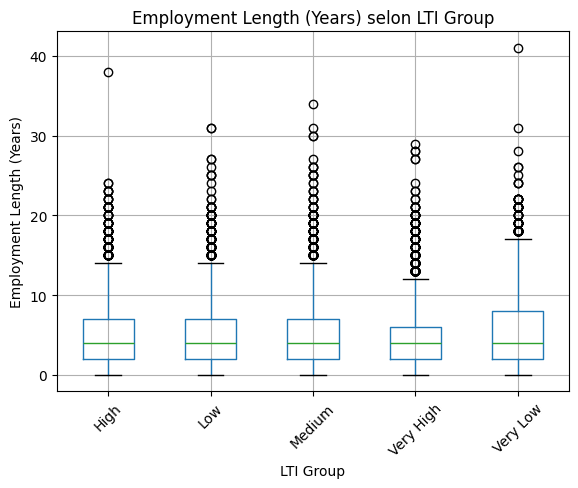

            count      mean       std  min  25%  50%  75%   max
LTI Group                                                      
High       6528.0  4.591605  3.846392  0.0  2.0  4.0  7.0  38.0
Low        5428.0  4.829956  4.041932  0.0  2.0  4.0  7.0  31.0
Medium     6157.0  4.737372  4.063625  0.0  2.0  4.0  7.0  34.0
Very High  5981.0  4.489049  3.852431  0.0  2.0  4.0  6.0  29.0
Very Low   7321.0  5.212676  4.283720  0.0  2.0  4.0  8.0  41.0


In [54]:
bivarié_cat_num(data, "LTI Group","Employment Length (Years)")


## Correlation des variables importantes avec l'échellon du pret

In [64]:
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)
features = {
    'Annual Income': 'Income',
    'Loan % of Income': 'LTI',
    'Employment Length (Years)': 'Employment Length',
    'Credit History Length (Years)': 'Credit History'
}

print(f"{'Variable':<25} {'Correlation avec Loan Grade':<25} {'R²':<10}")
print("-" * 60)

for col, label in features.items():
    r, p = stats.pearsonr(data['grade_numeric'], data[col])
    print(f"{label:<25} {r:<25.4f} {r**2:<10.4f}")

prev_numeric = (data['Previous Default'] == 'Yes').astype(int)
r, p = stats.pearsonr(data['grade_numeric'], prev_numeric)
print(f"{'Previous Default':<25} {r:<25.4f} {r**2:<10.4f}")

Variable                  Correlation avec Loan Grade R²        
------------------------------------------------------------
Income                    -0.0066                   0.0000    
LTI                       0.1241                    0.0154    
Employment Length         -0.0487                   0.0024    
Credit History            0.0133                    0.0002    
Previous Default          0.5359                    0.2872    


### Analyse de la raison des prets

C:\Users\user\AppData\Local\Temp\ipykernel_1760\3167752545.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


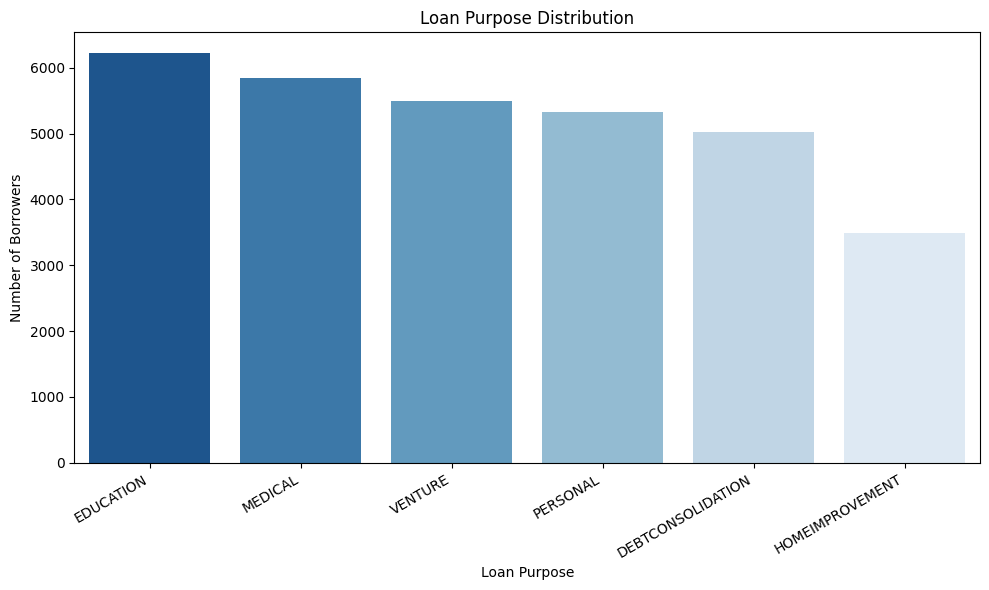

In [ ]:

plt.figure(figsize=(10,6))

order = data['Loan Purpose'].value_counts().index

sns.countplot(
    data=data,
    x='Loan Purpose',
    order=order,
    palette='Blues_r'
)

plt.title('Loan Purpose Distribution')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Borrowers')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("loan_purpose_distribution.png", bbox_inches='tight', dpi=300)
plt.show()


On voit que la plus grande proportions des prets des individus sont pour financer l'éducation.

### Analyse du defaut de paiement selon les differentes raison des prets

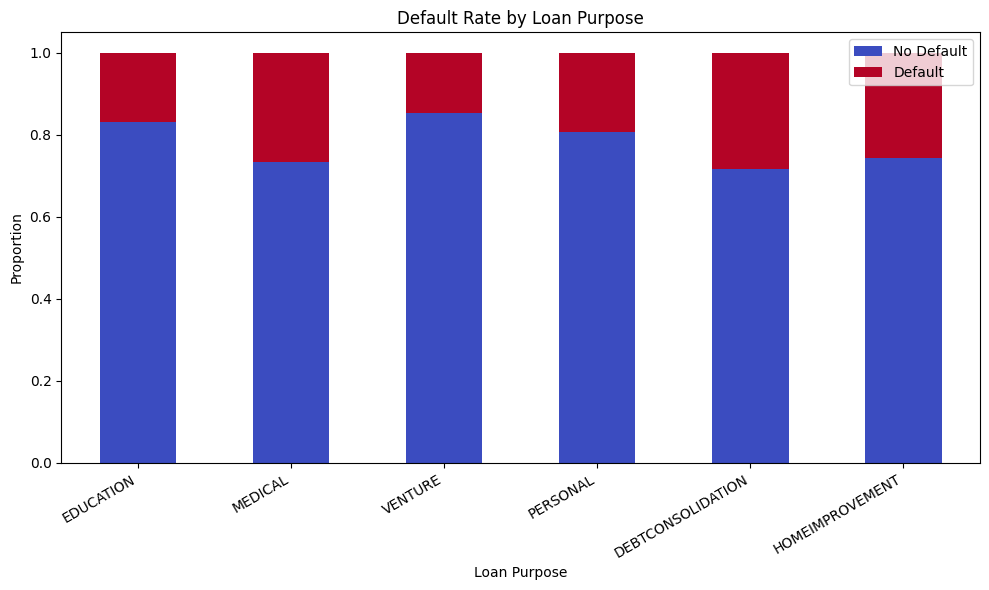

In [76]:
ct = pd.crosstab(
    data['Loan Purpose'],
    data['Default Status'],
    normalize='index'
)

ct = ct.loc[order]

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Default Rate by Loan Purpose')
plt.ylabel('Proportion')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=30, ha='right')
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.savefig("default_rate_by_loan_purpose.png", bbox_inches='tight', dpi=300)
plt.show()


### Analyse du taux de selon le statut de logement des emprunteurs.

C:\Users\user\AppData\Local\Temp\ipykernel_1760\1707149679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


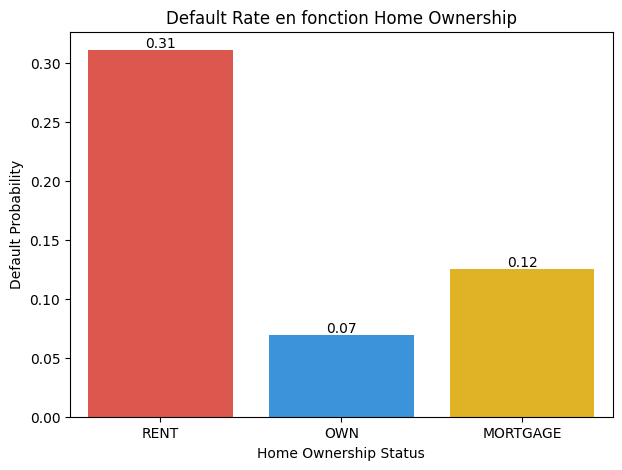

In [82]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x='Home Ownership',
    y='Default Status',
    data=data,
    order=['RENT', 'OWN', 'MORTGAGE'],
    palette=['#F44336', '#2196F3', '#FFC107'],
    errorbar=None
)

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Default Rate en fonction Home Ownership')
plt.xlabel('Home Ownership Status')
plt.ylabel('Default Probability')

plt.savefig("home_ownership_plot.png", bbox_inches='tight', dpi=300)
plt.show()


On remarque que la base de donnée est très deséquilibré comme on peut le voir ici environ 18% des prets des individus ne sont pas remboursées

In [83]:
data['Previous Default'].value_counts(normalize=True) * 100


Previous Default
No    82.22
Yes   17.78
Name: proportion, dtype: float64

### Defaut de paiement en fonction des précedents défauts

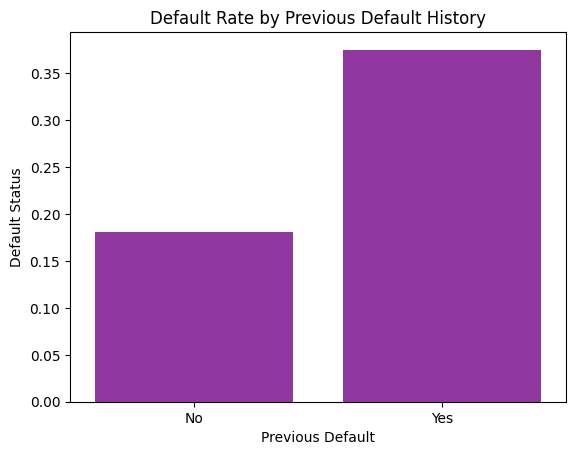

In [85]:
sns.barplot(x='Previous Default', y='Default Status', data=data, errorbar=None, color='#9C27B0')
plt.title('Default Rate by Previous Default History')
plt.savefig("previous_default_plot.png", bbox_inches='tight', dpi=300)
plt.show()

On voit ainsi que la situation de defaut precedent d'un client constitue une variable très importante pour anticiper si un individu paiera sa dette ou non.

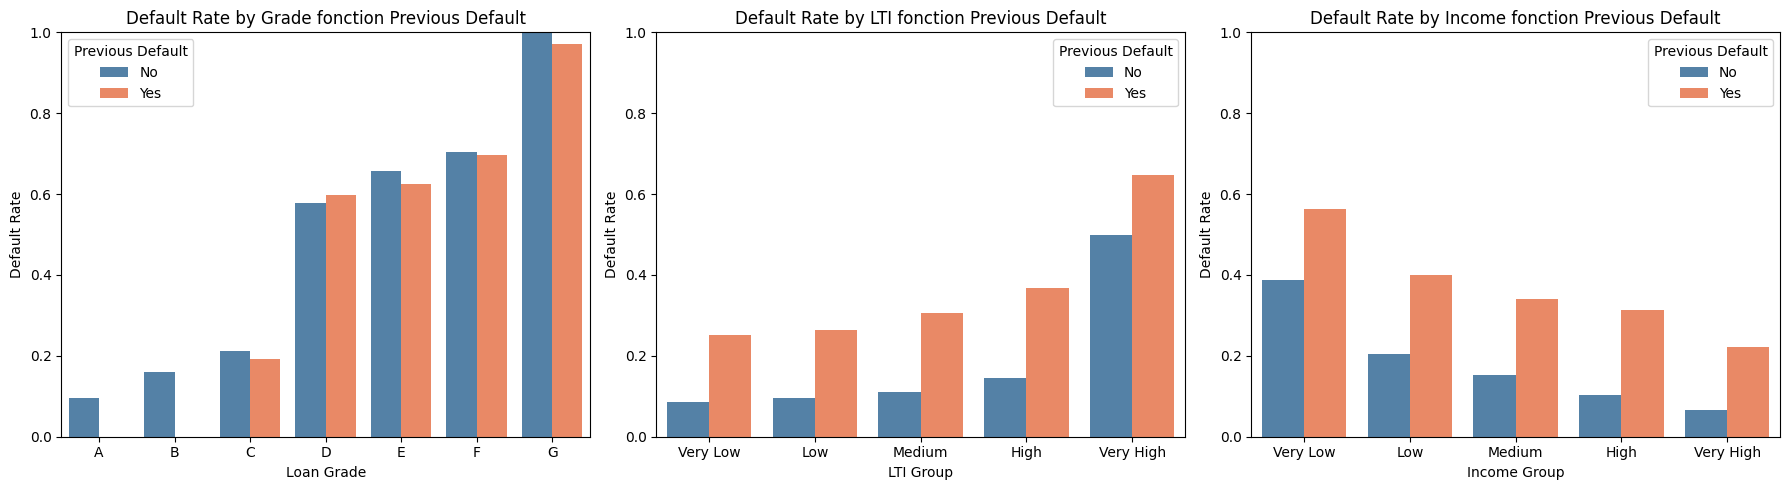

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create LTI Group before using it
data['LTI Group'] = pd.qcut(data['Loan % of Income'], q=5, labels=["Very Low","Low","Medium","High","Very High"])

# Create Income Group before using it
data['Income Group'] = pd.qcut(data['Annual Income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 1. Previous Default x Loan Grade
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grouped1 = (data.groupby(['Loan Grade', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

sns.barplot(data=grouped1, x='Loan Grade', y='default_rate',
            hue='Previous Default', order=grade_order,
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Default Rate by Grade fonction Previous Default')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, 1)

# 2. Previous Default x LTI Group
grouped2 = (data.groupby(['LTI Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
lti_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped2, x='LTI Group', y='default_rate',
            hue='Previous Default', order=lti_order,
            ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Default Rate by LTI fonction Previous Default')
axes[1].set_xlabel('LTI Group')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 1)

# 3. Previous Default x Income Group
grouped3 = (data.groupby(['Income Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped3, x='Income Group', y='default_rate',
            hue='Previous Default', order=income_order,
            ax=axes[2], palette=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Income fonction Previous Default')
axes[2].set_xlabel('Income Group')
axes[2].set_ylabel('Default Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()